# Dry Etch Process ODE Optimization
### CF4 RIE: SiO2 Etch Rate and Selectivity Optimization

Models a dry etch Design of Experiment (DOE) using a CF4 plasma etcher (RIE).
Two process parameters (**RF Power and Chamber Pressure**) are varied to map their effect on etch rate and selectivity. 
A response surface model is fitted to to identify the optimal process window where both outputs meet engineering specifications simultaneously. 

In [12]:
import numpy as np 
import pandas as pd
import scipy as stats
import matplotlib.pyplot as plt

## Step 1: DOE Grid & Data Generation
3x3 full factorial design across RF Power (100-300W) and Pressure (20-80 mTorr).

Higher RF Power → ions hit harder → faster etch rate, lower selectivity 
Higher Pressure → more collisions → slower etch rate, higher selectivity

In [13]:
# Step 1: Define DOE grid
# Varying RF Power (100-300 W) and Pressure (20-80 mTorr) across a 3x3 full factorial design
# Etch rate and selectivity modeled using physics-based equations with measurement noise

# RF Power (W) and Pressure (mTorr) - standard RIE ranges for CF4 oxide etch
power_levels = [100, 200, 300] # (W)
pressure_levels = [20, 50, 80] # (mTorr)

# Build all combinations (3x3 = 9 experiments)
experiments = [(p, pr) for p in power_levels for pr in pressure_levels]
df = pd.DataFrame(experiments, columns = ["RF_Power_W", "Pressure_mTorr"])

# Physics-based model for etch rate (nm/min)
# Higher power = faster etch | Higher pressure = slower etch
np.random.seed(42) # make results reproducible
noise = np.random.normal(0, 8, len(df)) # +/- 8 nm/min measurement noise

df["Etch_Rate"] = (
    120
    + 0.85 * df["RF_Power_W"] # power drives ion bombardment
    - 1.80 * df["Pressure_mTorr"] # pressure reduces mean free path
    + noise
)

# Physics-based model for selectivity (oxide : resist ratio)
# Higher power attacks resist more → selectivity drops
# Higher pressure = softer chemistry → selectivity improves
noise2 = np.random.normal(0, 0.15, len(df)) 

df["Selectivity"] = (
    6.5
    - 0.012 * df["RF_Power_W"]
    + 0.030 * df["Pressure_mTorr"]
    + noise2
).clip(1.0) # selectivity can't go below 1 (physically meaningless) in the parameters set here

print(df.round(2).to_string(index = False))                 

 RF_Power_W  Pressure_mTorr  Etch_Rate  Selectivity
        100              20     172.97         5.98
        100              50     113.89         6.73
        100              80      66.18         7.63
        200              20     266.18         4.74
        200              50     198.13         5.31
        200              80     144.13         6.24
        300              20     351.63         3.42
        300              50     291.14         4.25
        300              80     227.24         5.35


## Step 2 : Response Surface Model
Second-order polynimal fit using NumPy least squares to predict etch rate and selectivty across all possible power/pressure combinations.
Includes the interaction term (powerxpressure) to capture how the two variables affect each other.

In [18]:
# Step 2: Fit response surface models
# Fitting a 2nd order polynomial to map etch rate and selectivity
# to predict etch rate and selectivity at all possible power/pressure combinations beyond the 9 measured above

# Input features: RF Power and Pressure
X1 = df["RF_Power_W"].values
X2 = df["Pressure_mTorr"].values

# Generate polynomial features: 1, power, pressure, power^2, pressure^2, powerxpressure
# The interaction term (powerxpressure) represent how the two variables affect each other
X_poly = np.column_stack([
    np.ones(len(df)), # bias term
    X1, # power
    X2, # pressure
    X1**2, # power^2
    X2**2, # pressure^2
    X1 * X2 # interaction term
])

# Fit separate models for Etch Rate and Selectivity using least squares
coeffs_etch, _, _, _ = np.linalg.lstsq(X_poly, df["Etch_Rate"].values, rcond = None)
coeffs_sel, _, _, _ = np.linalg.lstsq(X_poly, df["Selectivity"].values, rcond = None)

# Calculate R^2 for each model
def r_squared(y_actual, y_predicted):
    ss_res = np.sum((y_actual - y_predicted)**2)
    ss_tot = np.sum((y_actual - np.mean(y_actual))**2)
    return 1 - (ss_res / ss_tot)

etch_pred_train = X_poly @ coeffs_etch
sel_pred_train = X_poly @ coeffs_sel

print(f"Etch Rate model R²: {r_squared(df['Etch_Rate'].values, etch_pred_train):.4f}")
print(f"Selectivity model R²: {r_squared(df['Selectivity'].values, sel_pred_train):.4f}")

# Generate fine grid for smoother contour lines
# Predict across 2500 combinations
power_range = np.linspace(100, 300, 50)
pressure_range = np.linspace(20, 80, 50)
P, PR = np.meshgrid(power_range, pressure_range)

# Flatten grid, build polynomial features, predict, reshape back into 2D surface
p_flat = P.ravel()
pr_flat = PR.ravel()

grid_poly = np.column_stack([
    np.ones(len(p_flat)),
    p_flat,
    pr_flat,
    p_flat **2,
    pr_flat **2,
    p_flat * pr_flat
])

etch_surface = (grid_poly @ coeffs_etch).reshape(P.shape)
sel_surface = (grid_poly @ coeffs_sel).reshape(P.shape)

print("Response surfaces generated -", etch_surface.shape, "grid points each") # confirm grid was created correctly

Etch Rate model R²: 0.9993
Selectivity model R²: 0.9977
Response surfaces generated - (50, 50) grid points each


## Step 3: Response Surface Contour Maps
Separate contour maps for etch rate and selectivity confirm the core engineering tradeoff - conditions that maximize one degrade the other.

Plot saved as response_surfaces.png


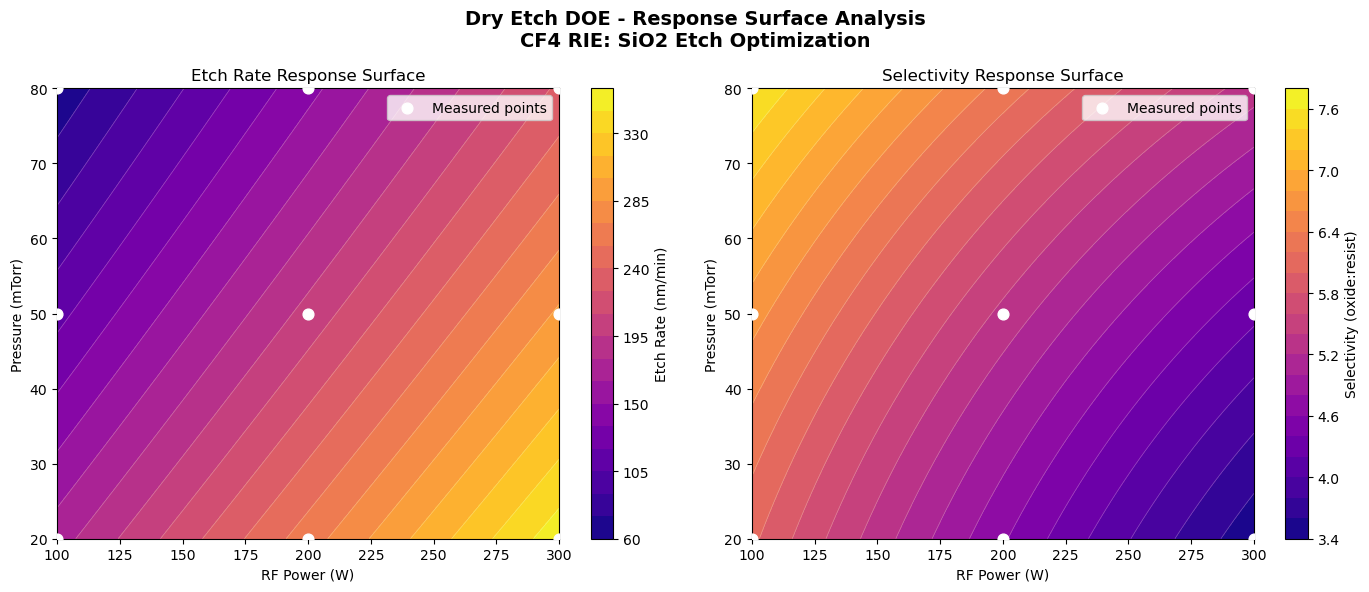

In [16]:
# Step 3: Plot response surfaces as contour maps
# Two separate contour maps (one for etch rate and one for selectivity)
# X-axis: RF Power | Y-axis: Presssure | Color: output value

fig, axes = plt.subplots(1, 2, figsize = (14, 6))
fig.suptitle("Dry Etch DOE - Response Surface Analysis\nCF4 RIE: SiO2 Etch Optimization",
            fontsize = 14, fontweight = "bold")

# Etch Rate contour map
cf1 = axes[0].contourf(P, PR, etch_surface, levels = 20, cmap = "plasma")
axes[0].contour(P, PR, etch_surface, levels = 20, colors = "white", alpha = 0.3, linewidths = 0.5)
plt.colorbar(cf1, ax=axes[0], label = "Etch Rate (nm/min)")
axes[0].scatter(df["RF_Power_W"], df["Pressure_mTorr"], 
                color = "white", s = 60, zorder = 5, label = "Measured points")
axes[0].set_xlabel("RF Power (W)")
axes[0].set_ylabel("Pressure (mTorr)")
axes[0].set_title("Etch Rate Response Surface")
axes[0].legend()

# Selectivity contour map
cf2 = axes[1].contourf(P, PR, sel_surface, levels = 20, cmap = "plasma")
axes[1].contour(P, PR, sel_surface, levels = 20, colors = "white", alpha = 0.3, linewidths = 0.5)
plt.colorbar(cf2, ax = axes[1], label = "Selectivity (oxide:resist)")
axes[1].scatter(df["RF_Power_W"], df["Pressure_mTorr"],
                color = "white", s = 60, zorder = 5, label = "Measured points")
axes[1].set_xlabel("RF Power (W)")
axes[1].set_ylabel("Pressure (mTorr)")
axes[1].set_title("Selectivity Response Surface")
axes[1].legend()

plt.tight_layout()
plt.savefig("response_surfaces.png", dpi = 150, bbox_inches = "tight")
plt.show

print("Plot saved as response_surfaces.png")

## Step 4: Process Window & Optimal Conditions
Process window: when both etch rate AND selectivity are within spec 
- Etch Rate target >= 200 nm/min (min acceptable throughput)
- Selectivity target >= 3.5 (min req to guarantee that mask outlasts the etch)

Optimal point identified while maximizing selectivity within the process window. 

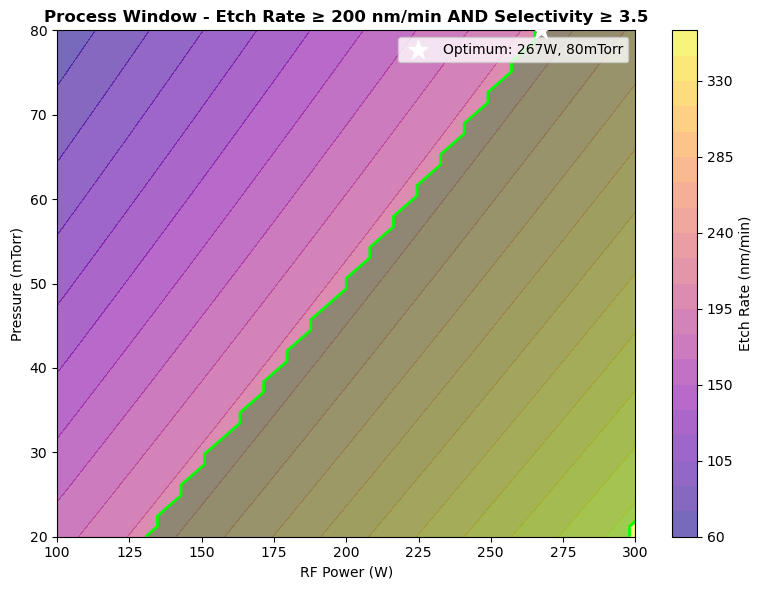

,Parameter,Optimal Value,Spec
0,RF Power,267 W,-
1,Pressure,80 mTorr,-
2,Etch Rate,200.7 nm/min,≥ 200 nm/min
3,Selectivity,5.60,≥ 3.5


In [17]:
# Step 4: Find the optimal process window
# Process window = region where etch rate AND selectivity are both within spec
# Etch Rate target >= 200 nm/min (min acceptable throughput)
# Selectivity target >= 3.5 (min req to guarantee that mask outlasts the etch)

etch_min = 200
sel_min = 3.5

# Find all grid points where both specs are met simultaneously 
process_window = (etch_surface >= etch_min) & (sel_surface >= sel_min)

# Find optimal point - highest selectivity within the process window
sel_in_window = np.where(process_window, sel_surface, np.nan)
opt_idx = np.unravel_index(np.nanargmax(sel_in_window), sel_surface.shape)
opt_power = P[opt_idx]
opt_pressure = PR[opt_idx]
opt_etch = etch_surface[opt_idx]
opt_sel = sel_surface[opt_idx]

# Plot process window
fig, ax = plt.subplots(figsize = (8, 6))
cf = ax.contourf(P, PR, etch_surface, levels = 20, cmap = "plasma", alpha = 0.6)
plt.colorbar(cf, ax = ax, label = "Etch Rate (nm/min)")

# Overlay process window in green
ax.contourf(P, PR, process_window.astype(float),
            levels = [0.5, 1.5], colors =["green"], alpha = 0.35)
ax.contour(P, PR, process_window.astype(float),
           levels = [0.5], colors = "lime", linewidths = 2)

# Mark optimal point
ax.scatter(opt_power, opt_pressure, color = "white", s = 200,
           marker = "*", zorder = 6, label = f"Optimum: {opt_power:.0f}W, {opt_pressure:.0f}mTorr")

ax.set_xlabel("RF Power (W)")
ax.set_ylabel("Pressure (mTorr)")
ax.set_title("Process Window - Etch Rate ≥ 200 nm/min AND Selectivity ≥ 3.5",
                fontweight = "bold")
ax.legend()
plt.tight_layout()
plt.savefig("process_window.png", dpi = 150, bbox_inches = "tight")
plt.show()

results = pd.DataFrame({
    "Parameter": ["RF Power", "Pressure", "Etch Rate", "Selectivity"],
    "Optimal Value": [f"{opt_power:.0f} W", f"{opt_pressure:.0f} mTorr", f"{opt_etch:.1f} nm/min", f"{opt_sel:.2f}"], 
    "Spec": ["-", "-", "≥ 200 nm/min", "≥ 3.5"]
})
display(results)